In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num = 26 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 3500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell   
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 

## Step 0: Get loaded data 

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c26_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c26_patch.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

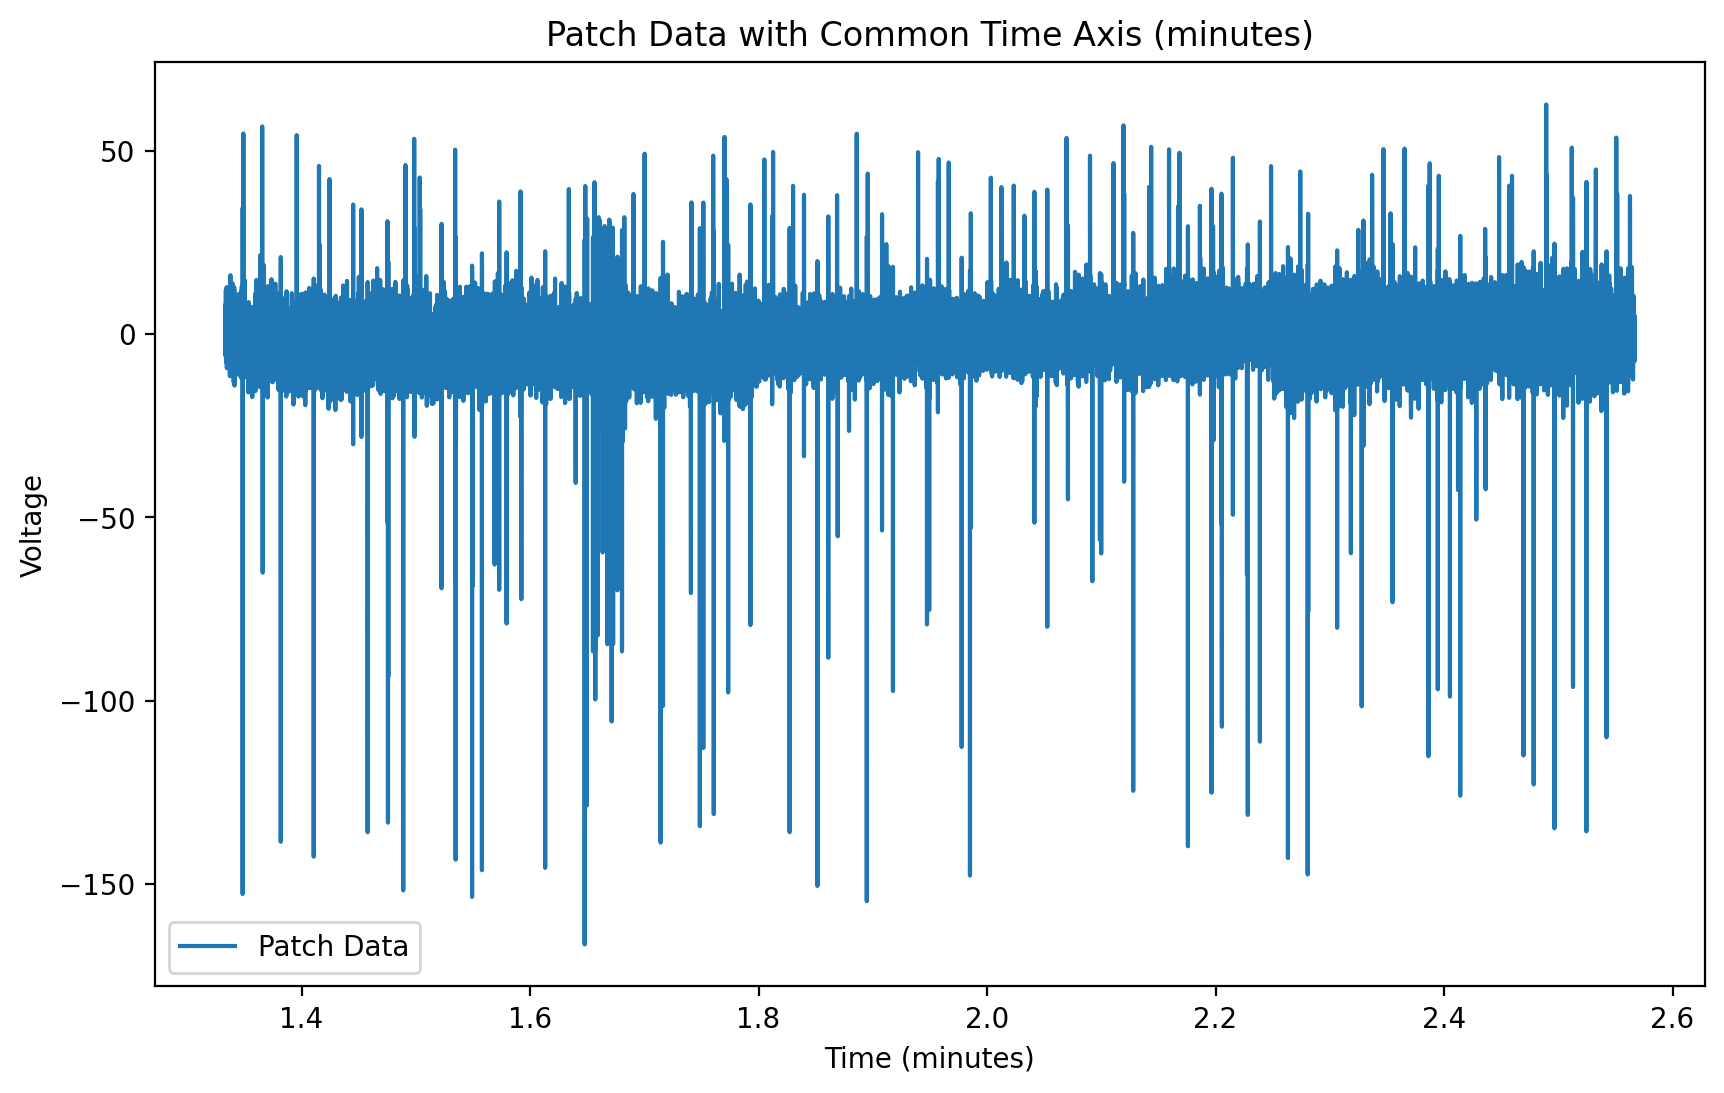

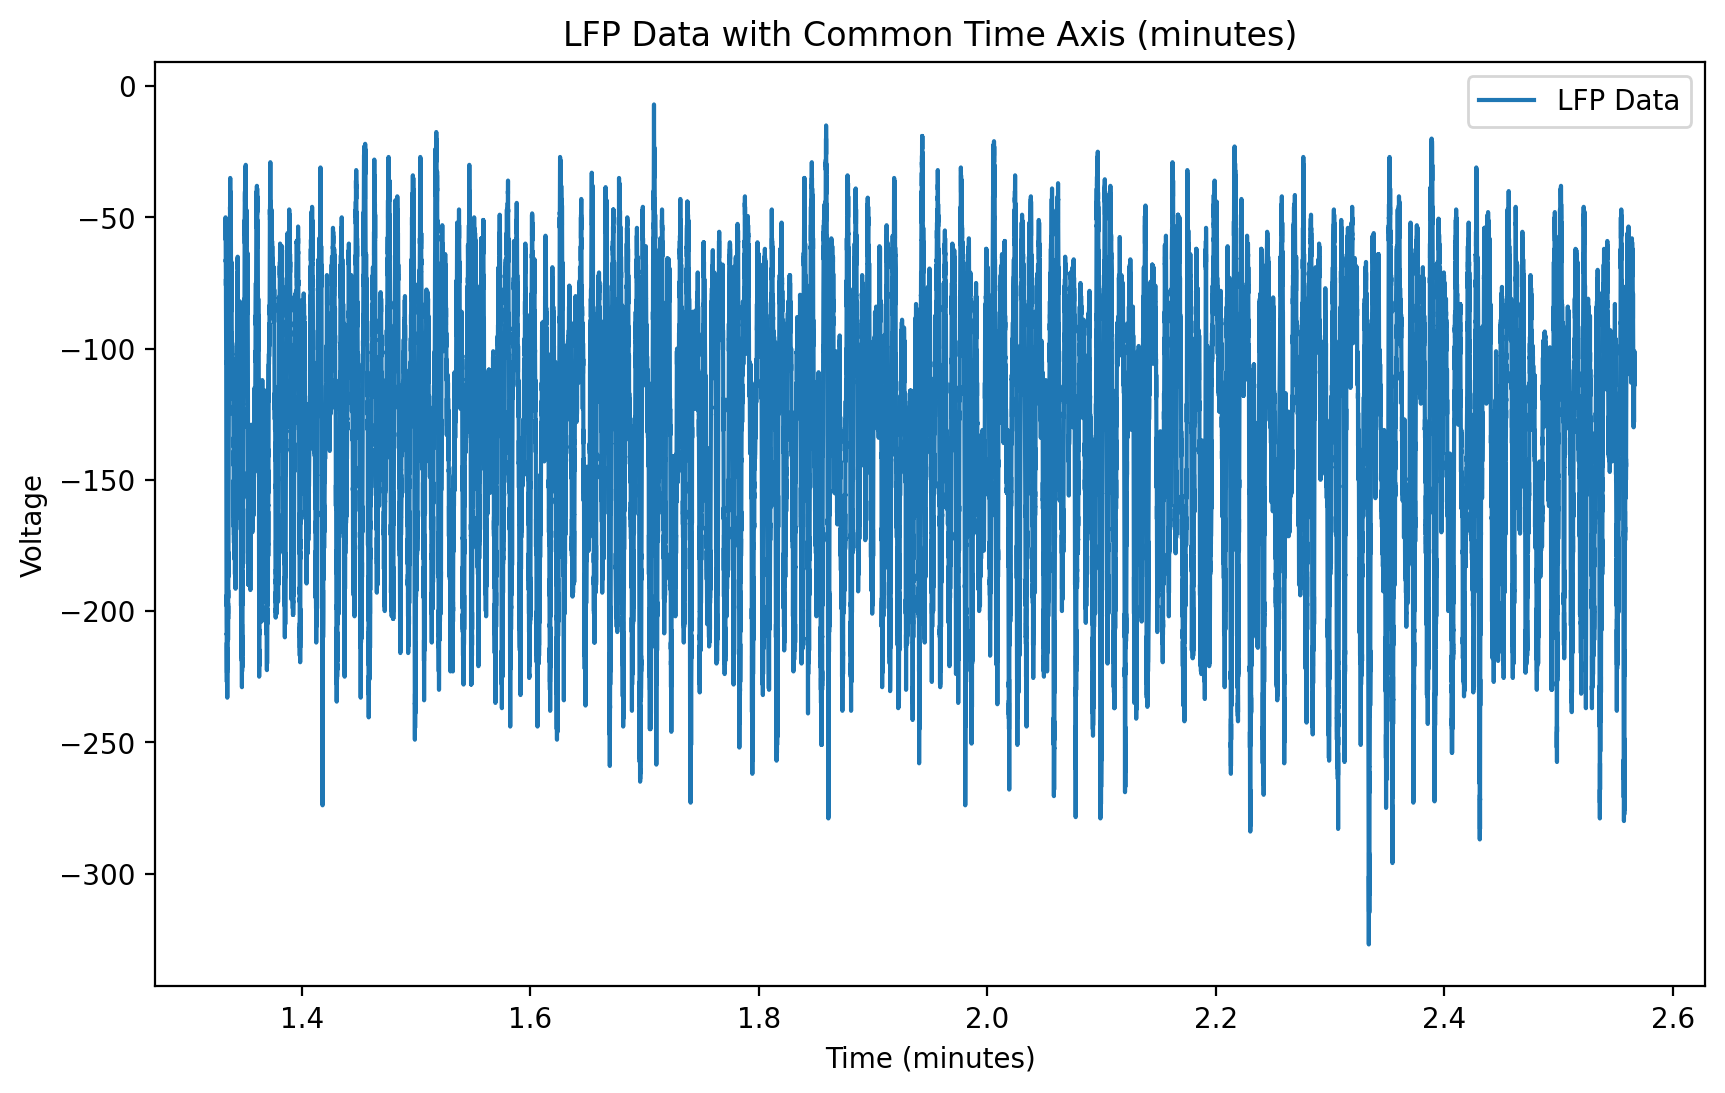

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 35.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

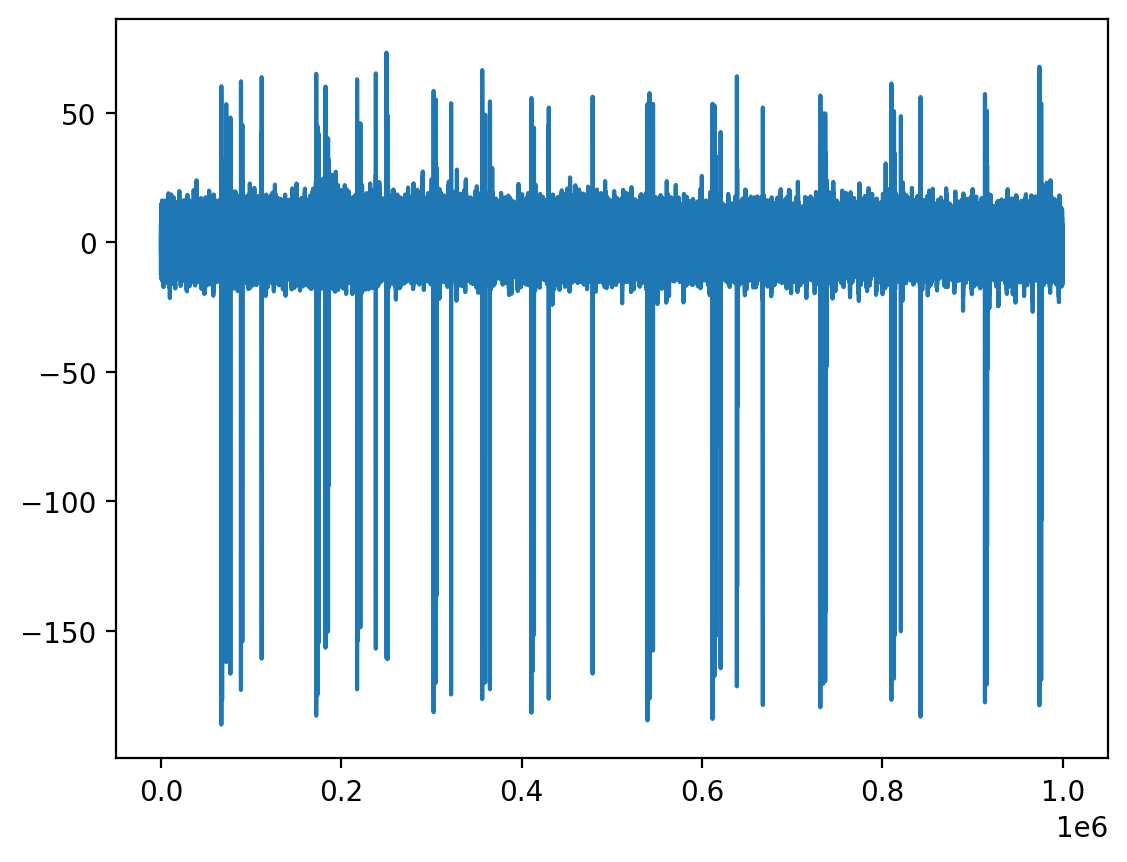

In [7]:
plt.plot(patch_filt[:1000000] )

In [8]:



#threshold in mVs
sp = Spike(thresh_amp=80, window_length=(5., 5.), smooth_frac=.01)

In [9]:
#CHANGE FOR EACH CELL
sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=True)

Spike:   0%|          | 0/4039 [00:00<?, ?it/s]

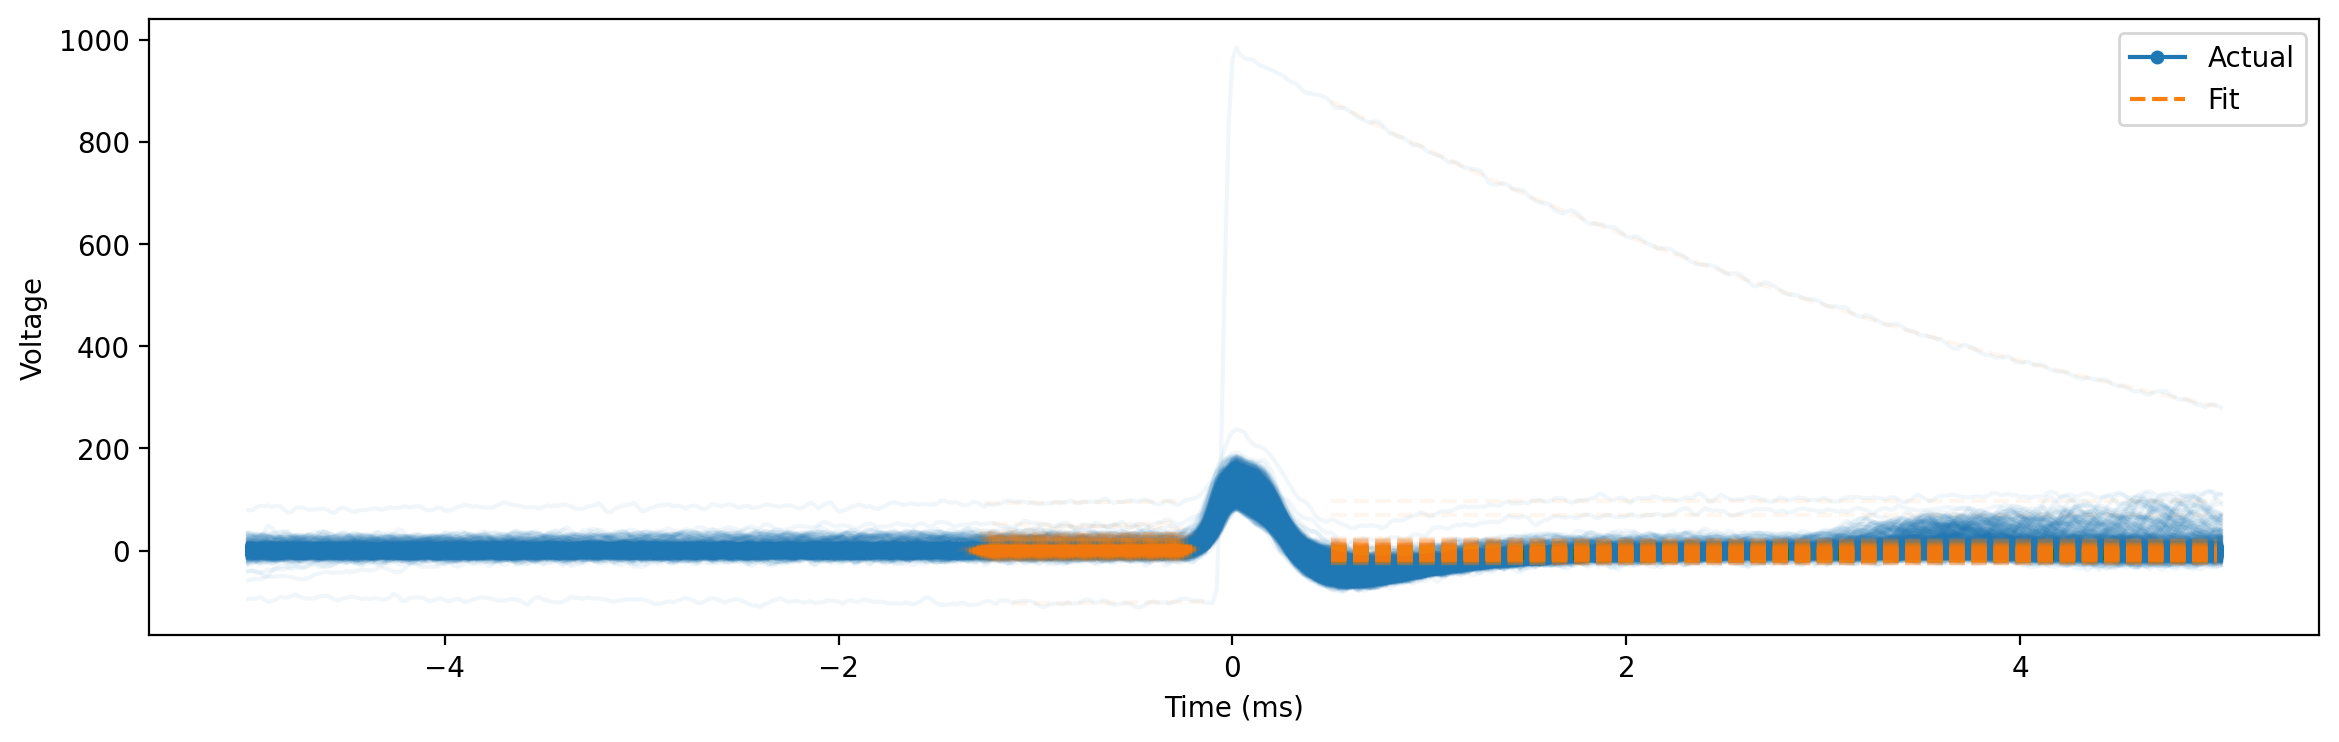

In [10]:
sp.plot()

### Filter spikes 

In [11]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [12]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [13]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,4.772764,0.26,6.182751,185.042037,0.32,46.383072,0.000036,-4.359983,1.392138,66990,1.339160e+03,0
1,0.380439,0.32,-2.201683,107.099109,0.32,30.214680,0.000009,-4.812033,1.921479,68224,1.363828e+03,1
2,2.211936,0.26,2.832767,158.466320,0.34,59.216110,0.000007,-11.653765,1.968182,72399,1.447289e+03,2
3,0.985446,0.26,7.874414,165.987646,0.34,50.042921,0.000025,-3.253627,2.369379,77048,1.540224e+03,3
4,0.567149,0.26,-5.350459,168.571522,0.34,59.164993,0.000011,-8.066550,1.485798,88758,1.774312e+03,4
...,...,...,...,...,...,...,...,...,...,...,...,...
4034,4.988570,0.26,-1.817283,124.515117,0.24,53.138013,0.000007,-4.647887,1.509533,60702370,1.213468e+06,4034
4035,0.872070,0.26,6.006340,80.464234,0.26,33.876142,0.000015,-4.762126,2.472227,60703987,1.213500e+06,4035
4036,-1.880730,0.24,3.151432,126.439418,0.28,55.537584,0.000004,-8.574827,2.945005,60718826,1.213797e+06,4036
4037,0.723231,0.22,8.408160,135.970990,0.24,54.933610,0.000004,-8.222230,1.977059,60762900,1.214678e+06,4037


### Get spike times


In [14]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

In [15]:
df_features.columns

Index(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp',
       'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const', 'log_isi',
       'spk_times_idx', 'spk_times_ms', 'spk_id'],
      dtype='str')

## STEP 2: Cluster spike groups 

#### Plot distribution of all features

Plotting spike features...
Removing outliers using IQR method (multiplier=3)


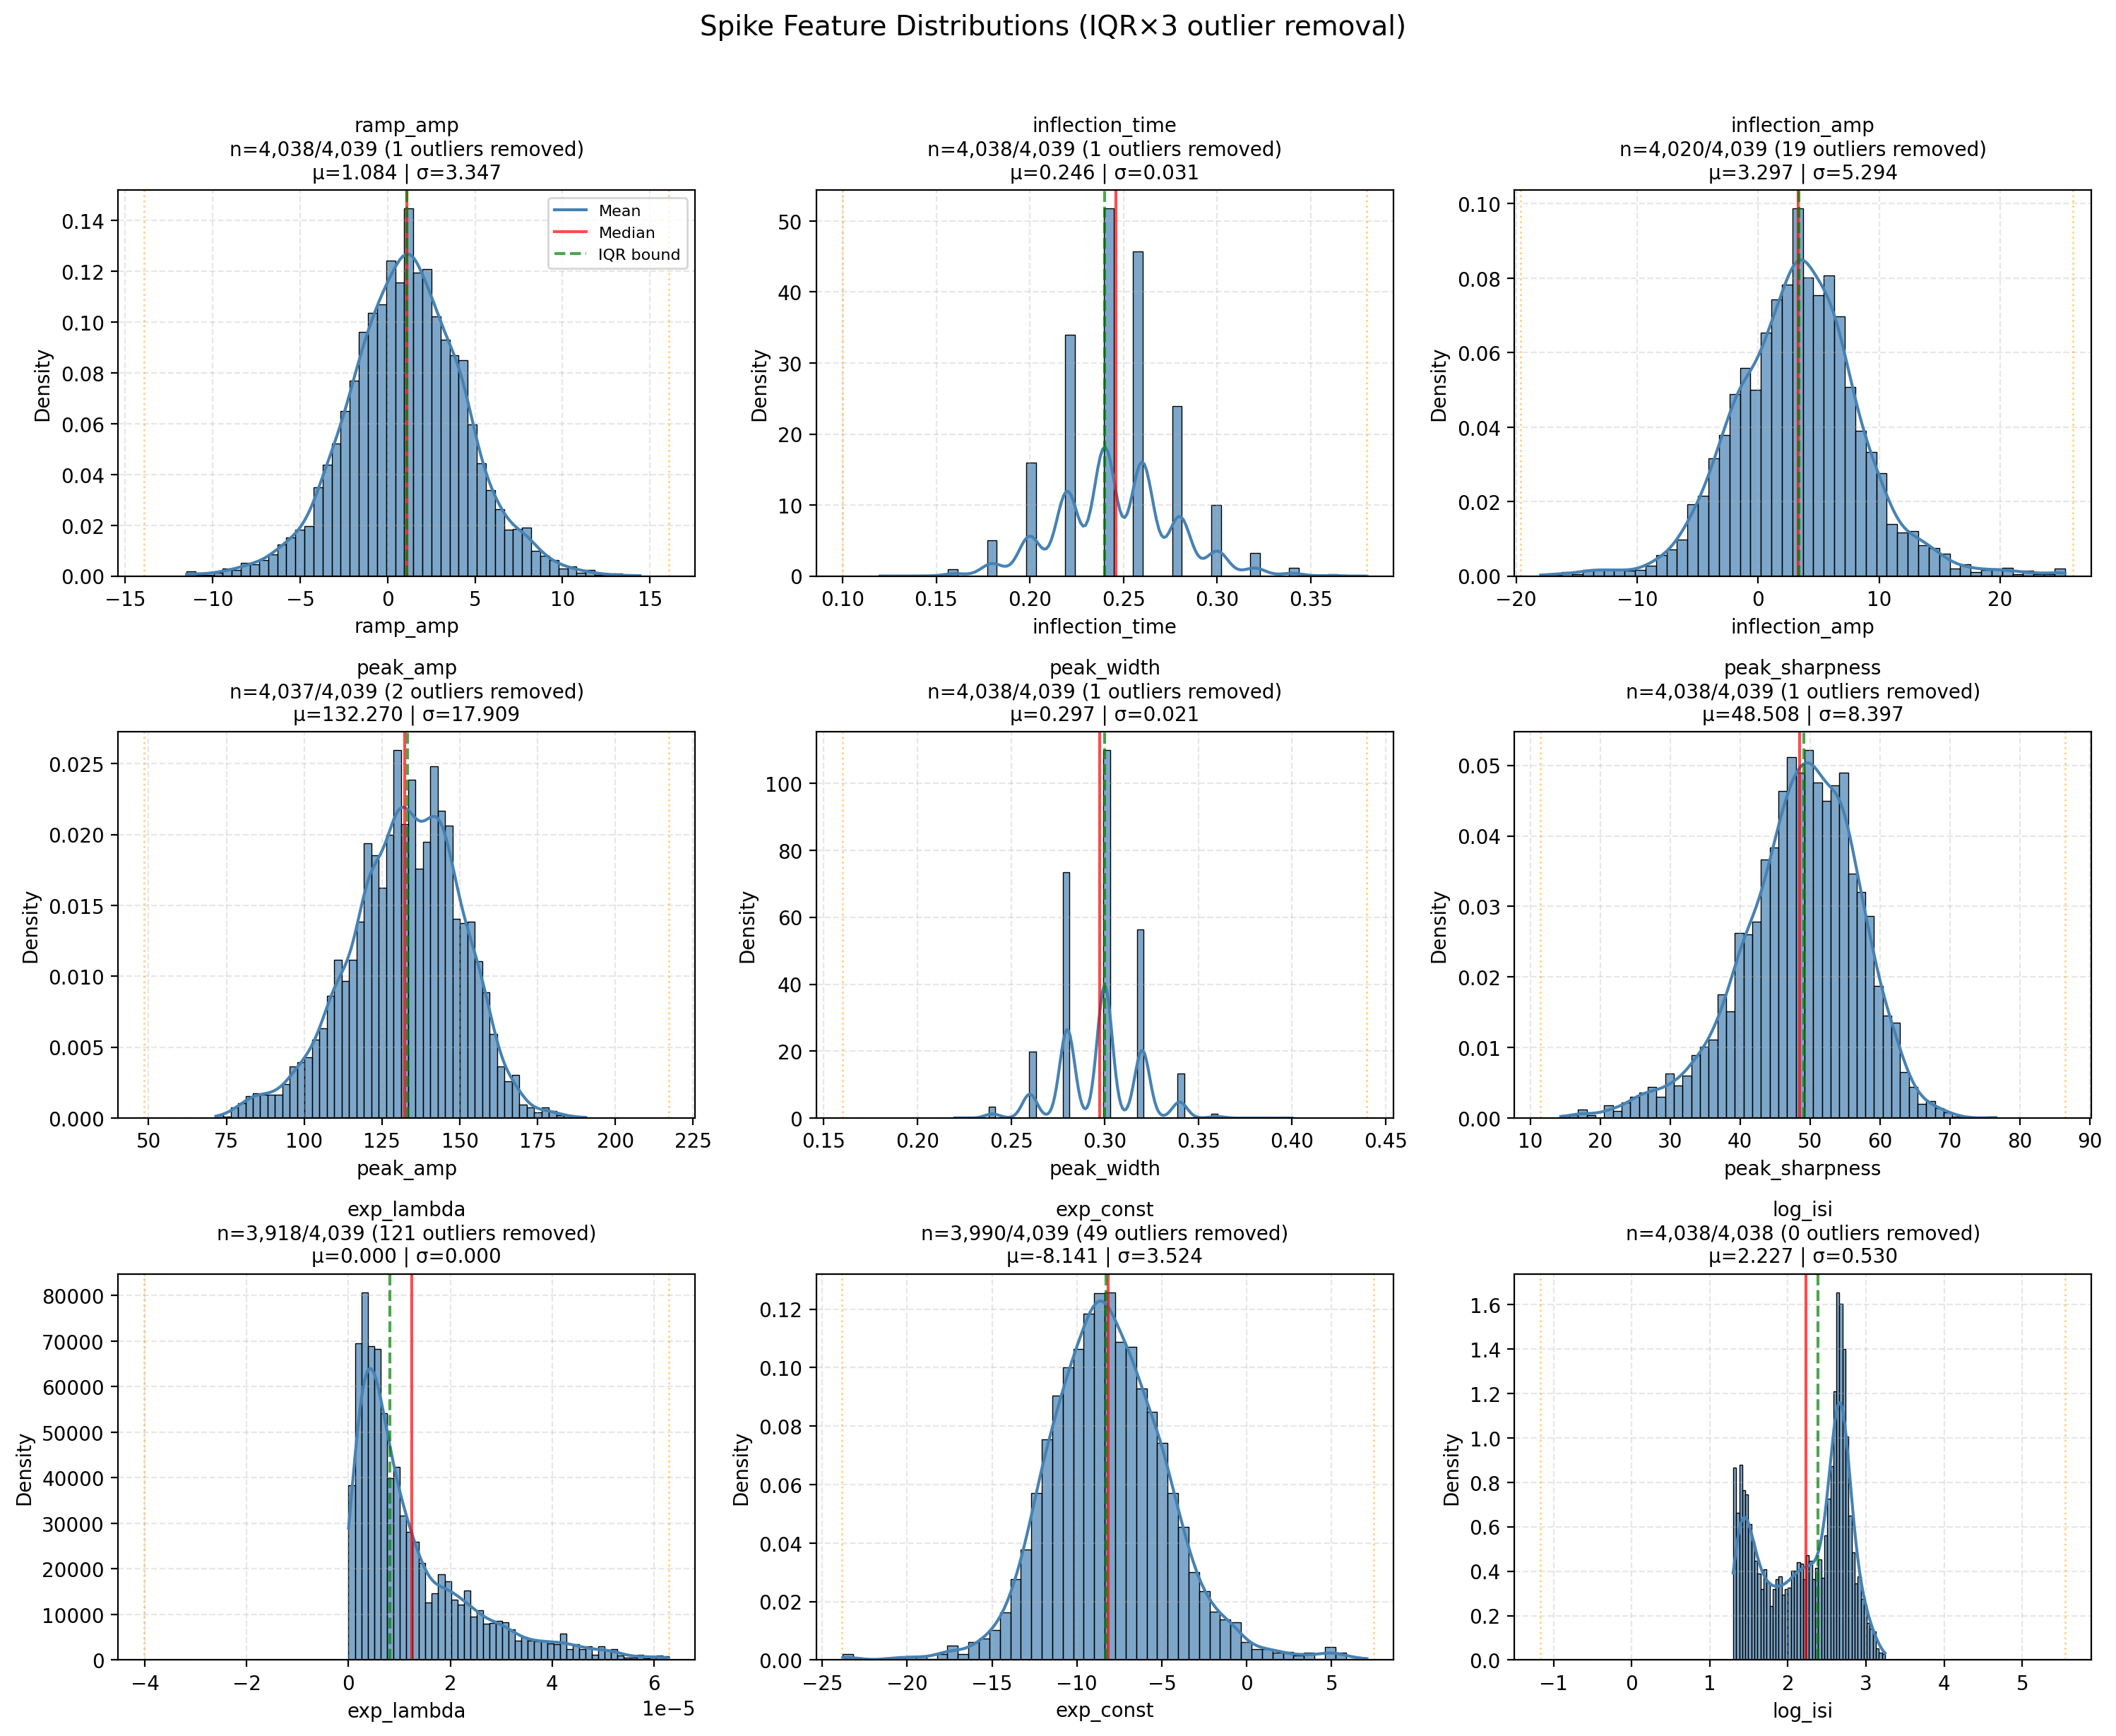


FEATURE DISTRIBUTION SUMMARY
Feature              Total N    Clean N    Outliers   % Removed  Mean       Std       
------------------------------------------------------------------------------------------
ramp_amp             4039       4038       1          0.0        1.084      3.347     
inflection_time      4039       4038       1          0.0        0.246      0.031     
inflection_amp       4039       4020       19         0.5        3.297      5.294     
peak_amp             4039       4037       2          0.0        132.270    17.909    
peak_width           4039       4038       1          0.0        0.297      0.021     
peak_sharpness       4039       4038       1          0.0        48.508     8.397     
exp_lambda           4039       3918       121        3.0        0.000      0.000     
exp_const            4039       3990       49         1.2        -8.141     3.524     
log_isi              4038       4038       0          0.0        2.227      0.530     


In [16]:
plot_spike_feature_distributions(df_features)

ramp_amp: Skipped - k_suggest = 1
→ inflection_time: Skipping (feature ignored).
inflection_amp: Skipped - k_suggest = 1
peak_amp: Skipped - k_suggest = 1
peak_width: Skipped - k_suggest = 1
peak_sharpness: Skipped - k_suggest = 1
exp_lambda: Skipped - k_suggest = 1
exp_const: Skipped - k_suggest = 1


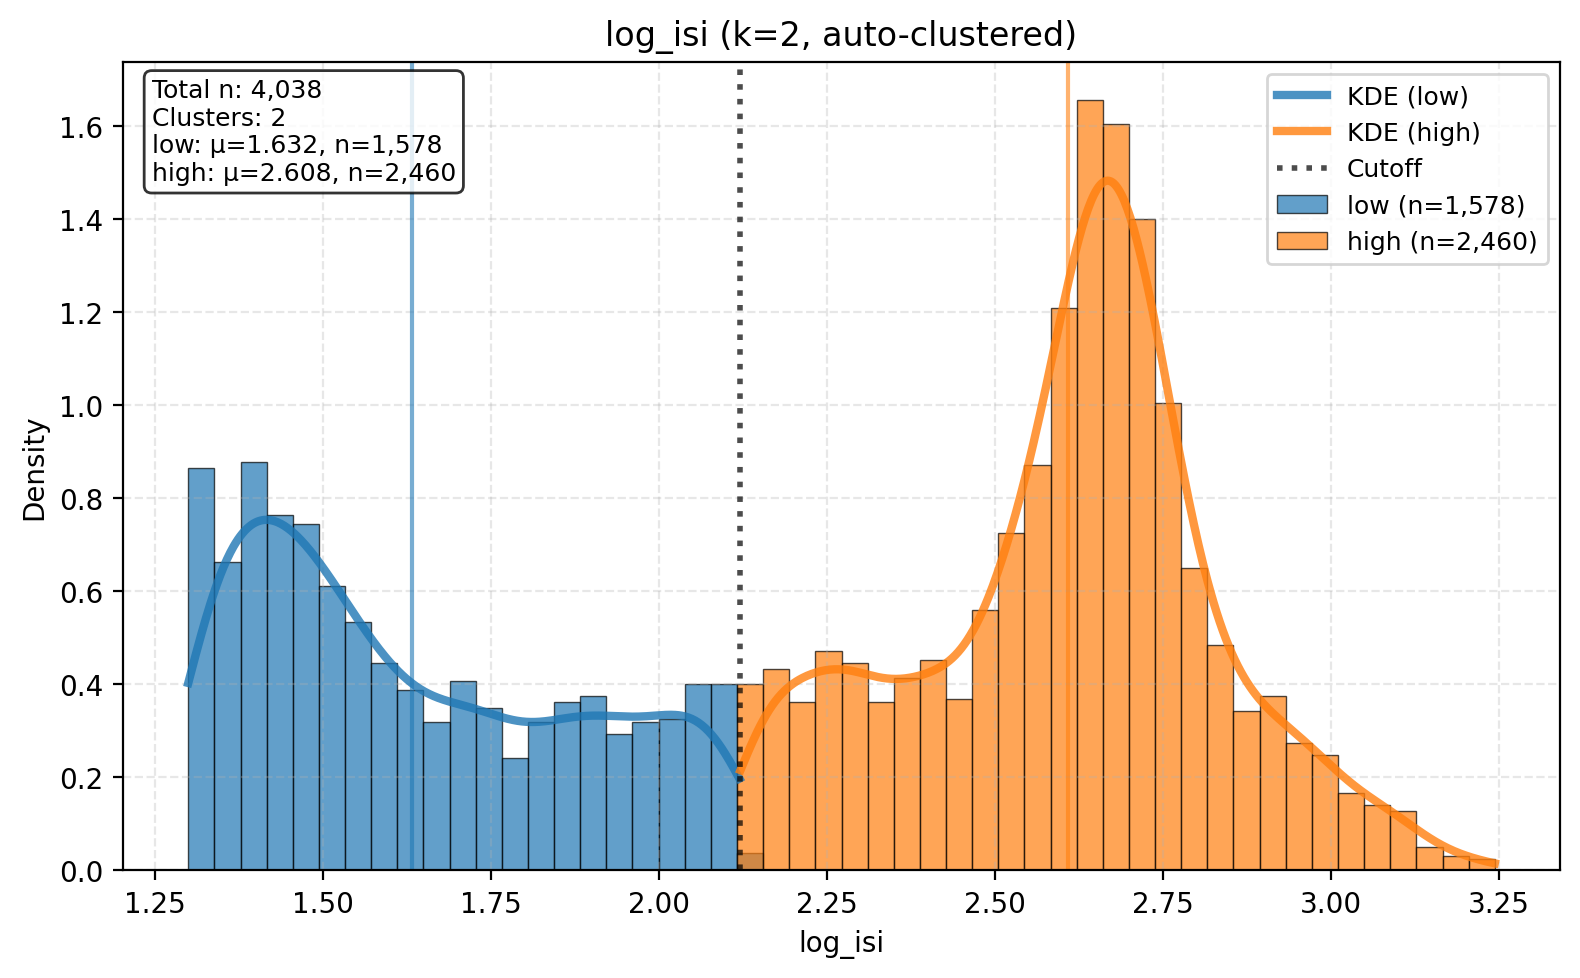

spk_times_idx: Skipped - k_suggest = 1
spk_times_ms: Skipped - k_suggest = 1
spk_id: Skipped - k_suggest = 1


In [17]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features,
    max_k=2, ignore_features = "inflection_time",
    suffix="_cluster",
    plot_each=True,  # set True if you want a quick plot per clustered feature, 
    manual_thresholds={
    }
)





===== CLUSTER REPORT: log_isi_cluster =====
Found 2 clusters: ['high', 'low']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low']
  Groups: ('low', 'high')
  Group names: ('Low', 'High')

→ 1. Plotting spike waveforms by cluster

→ 1.5 Average waveforms with visual RMSE


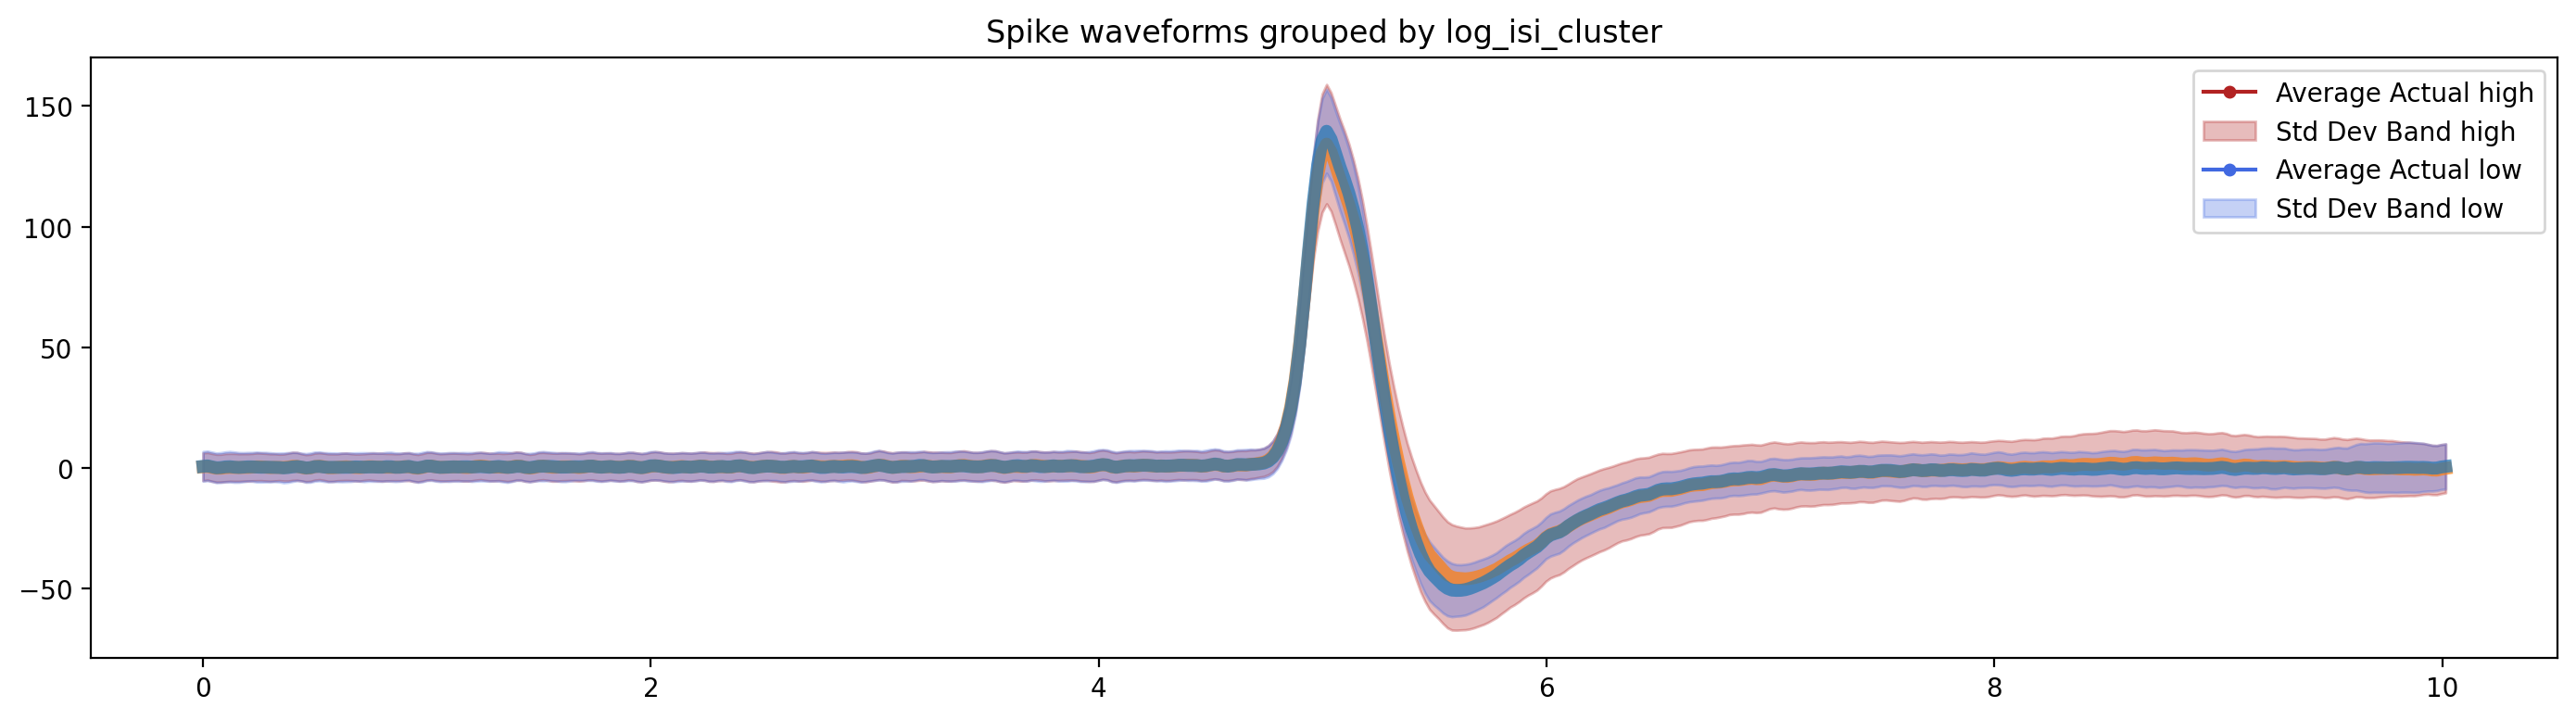

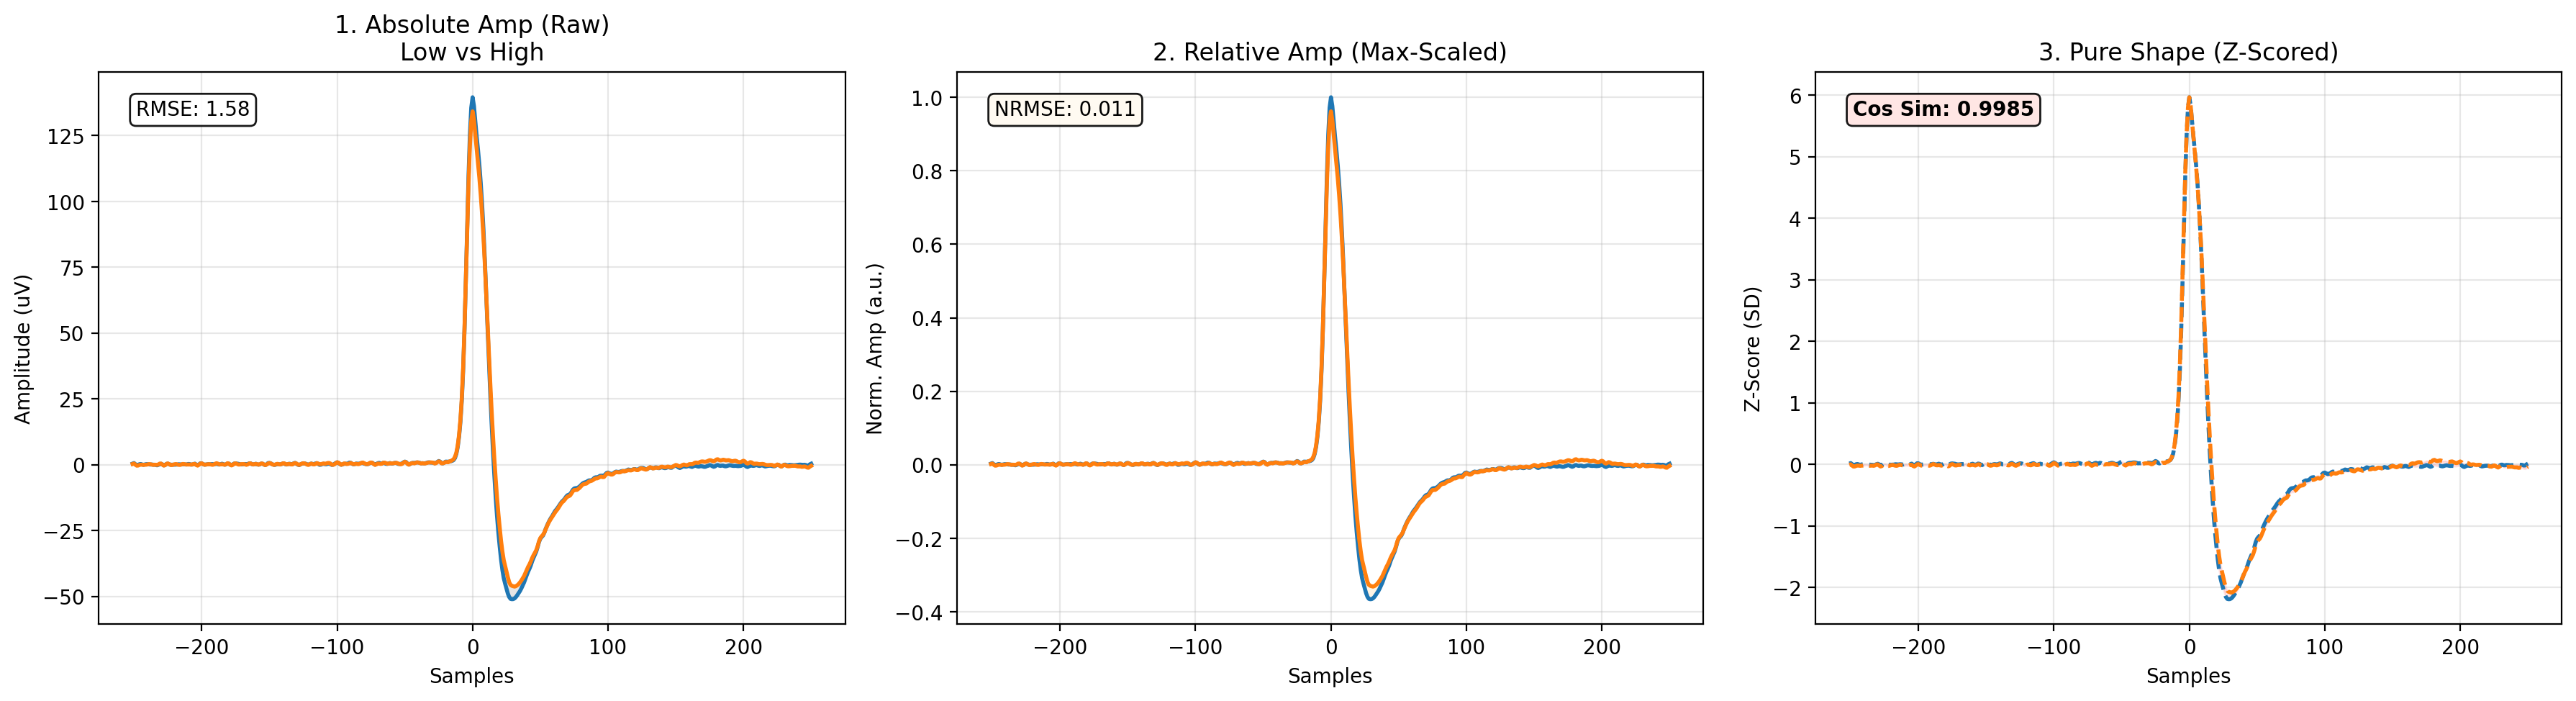


→ 2. Plotting cluster proportions over time


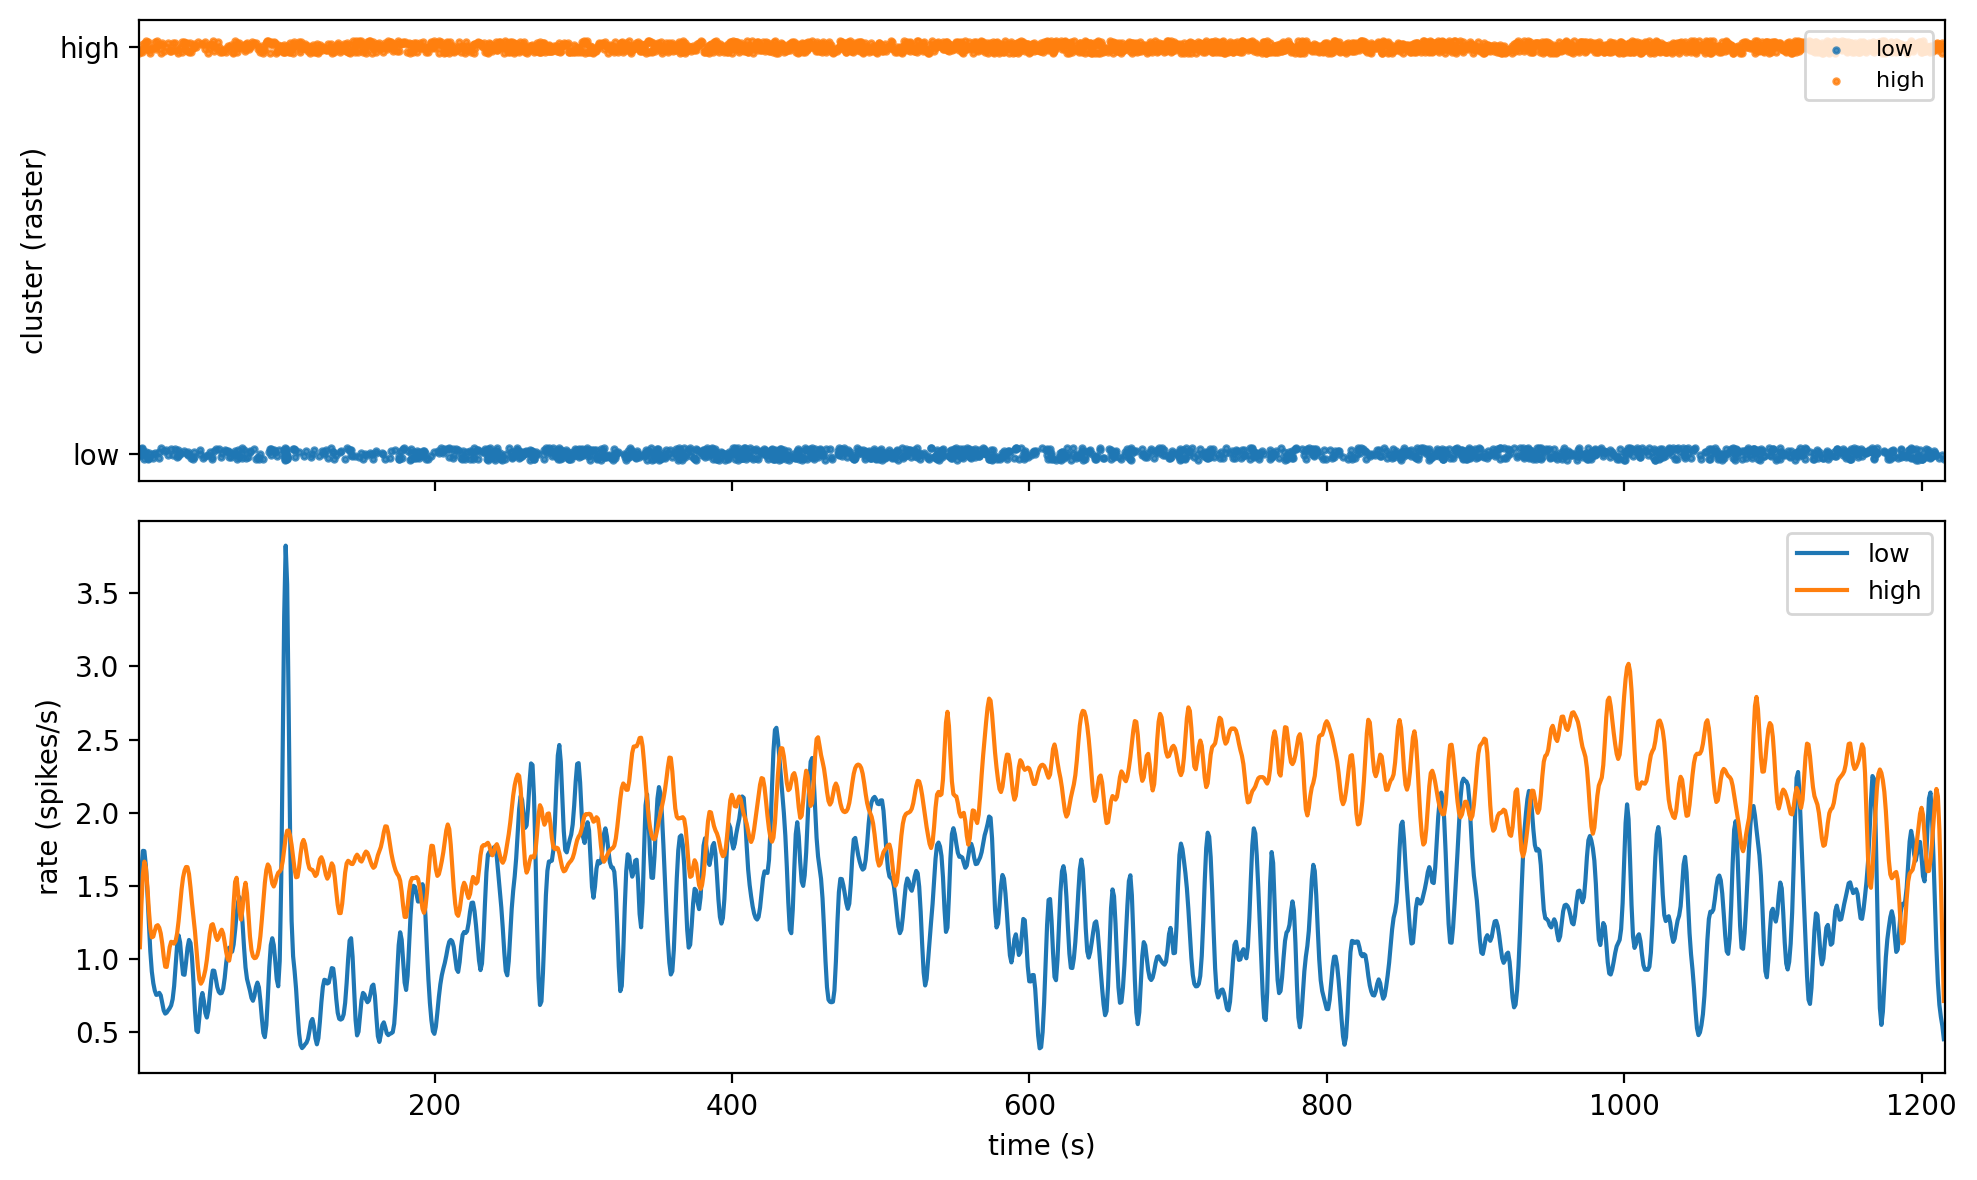


→ 3. Computing cluster transition matrix


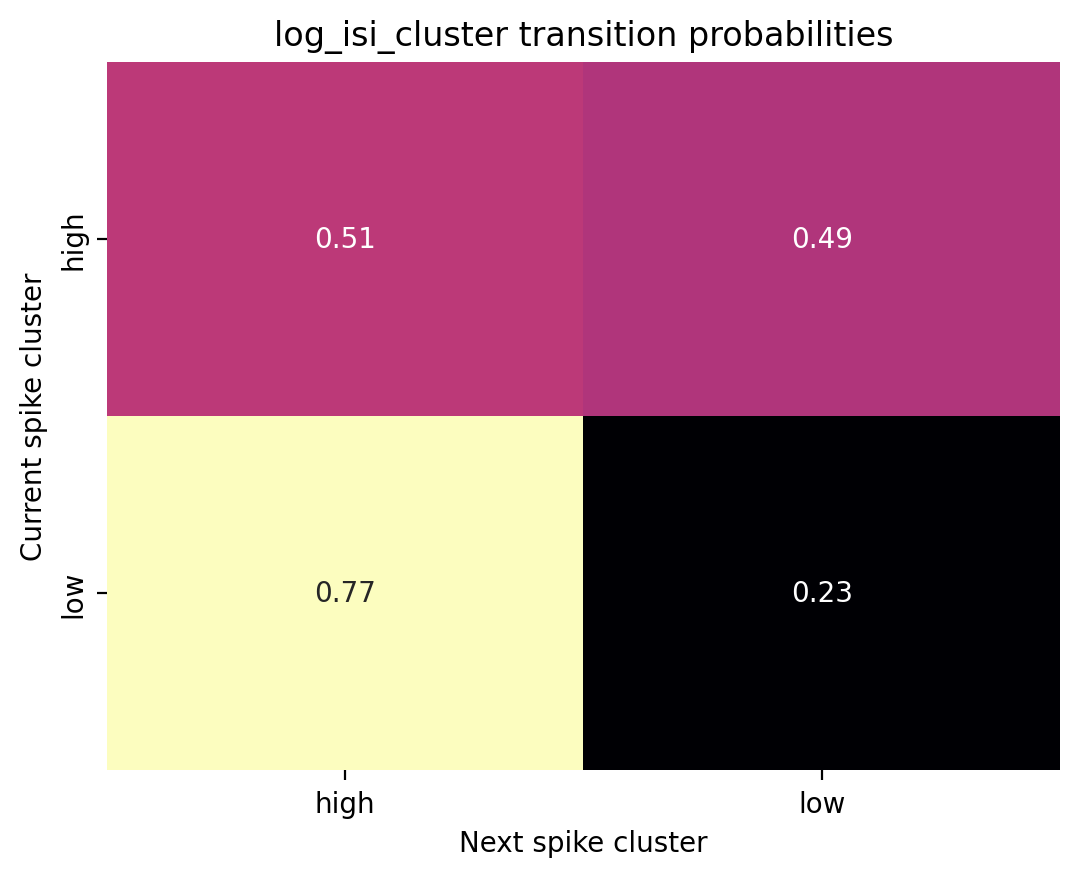


→ 4. Visualizing feature distributions by cluster


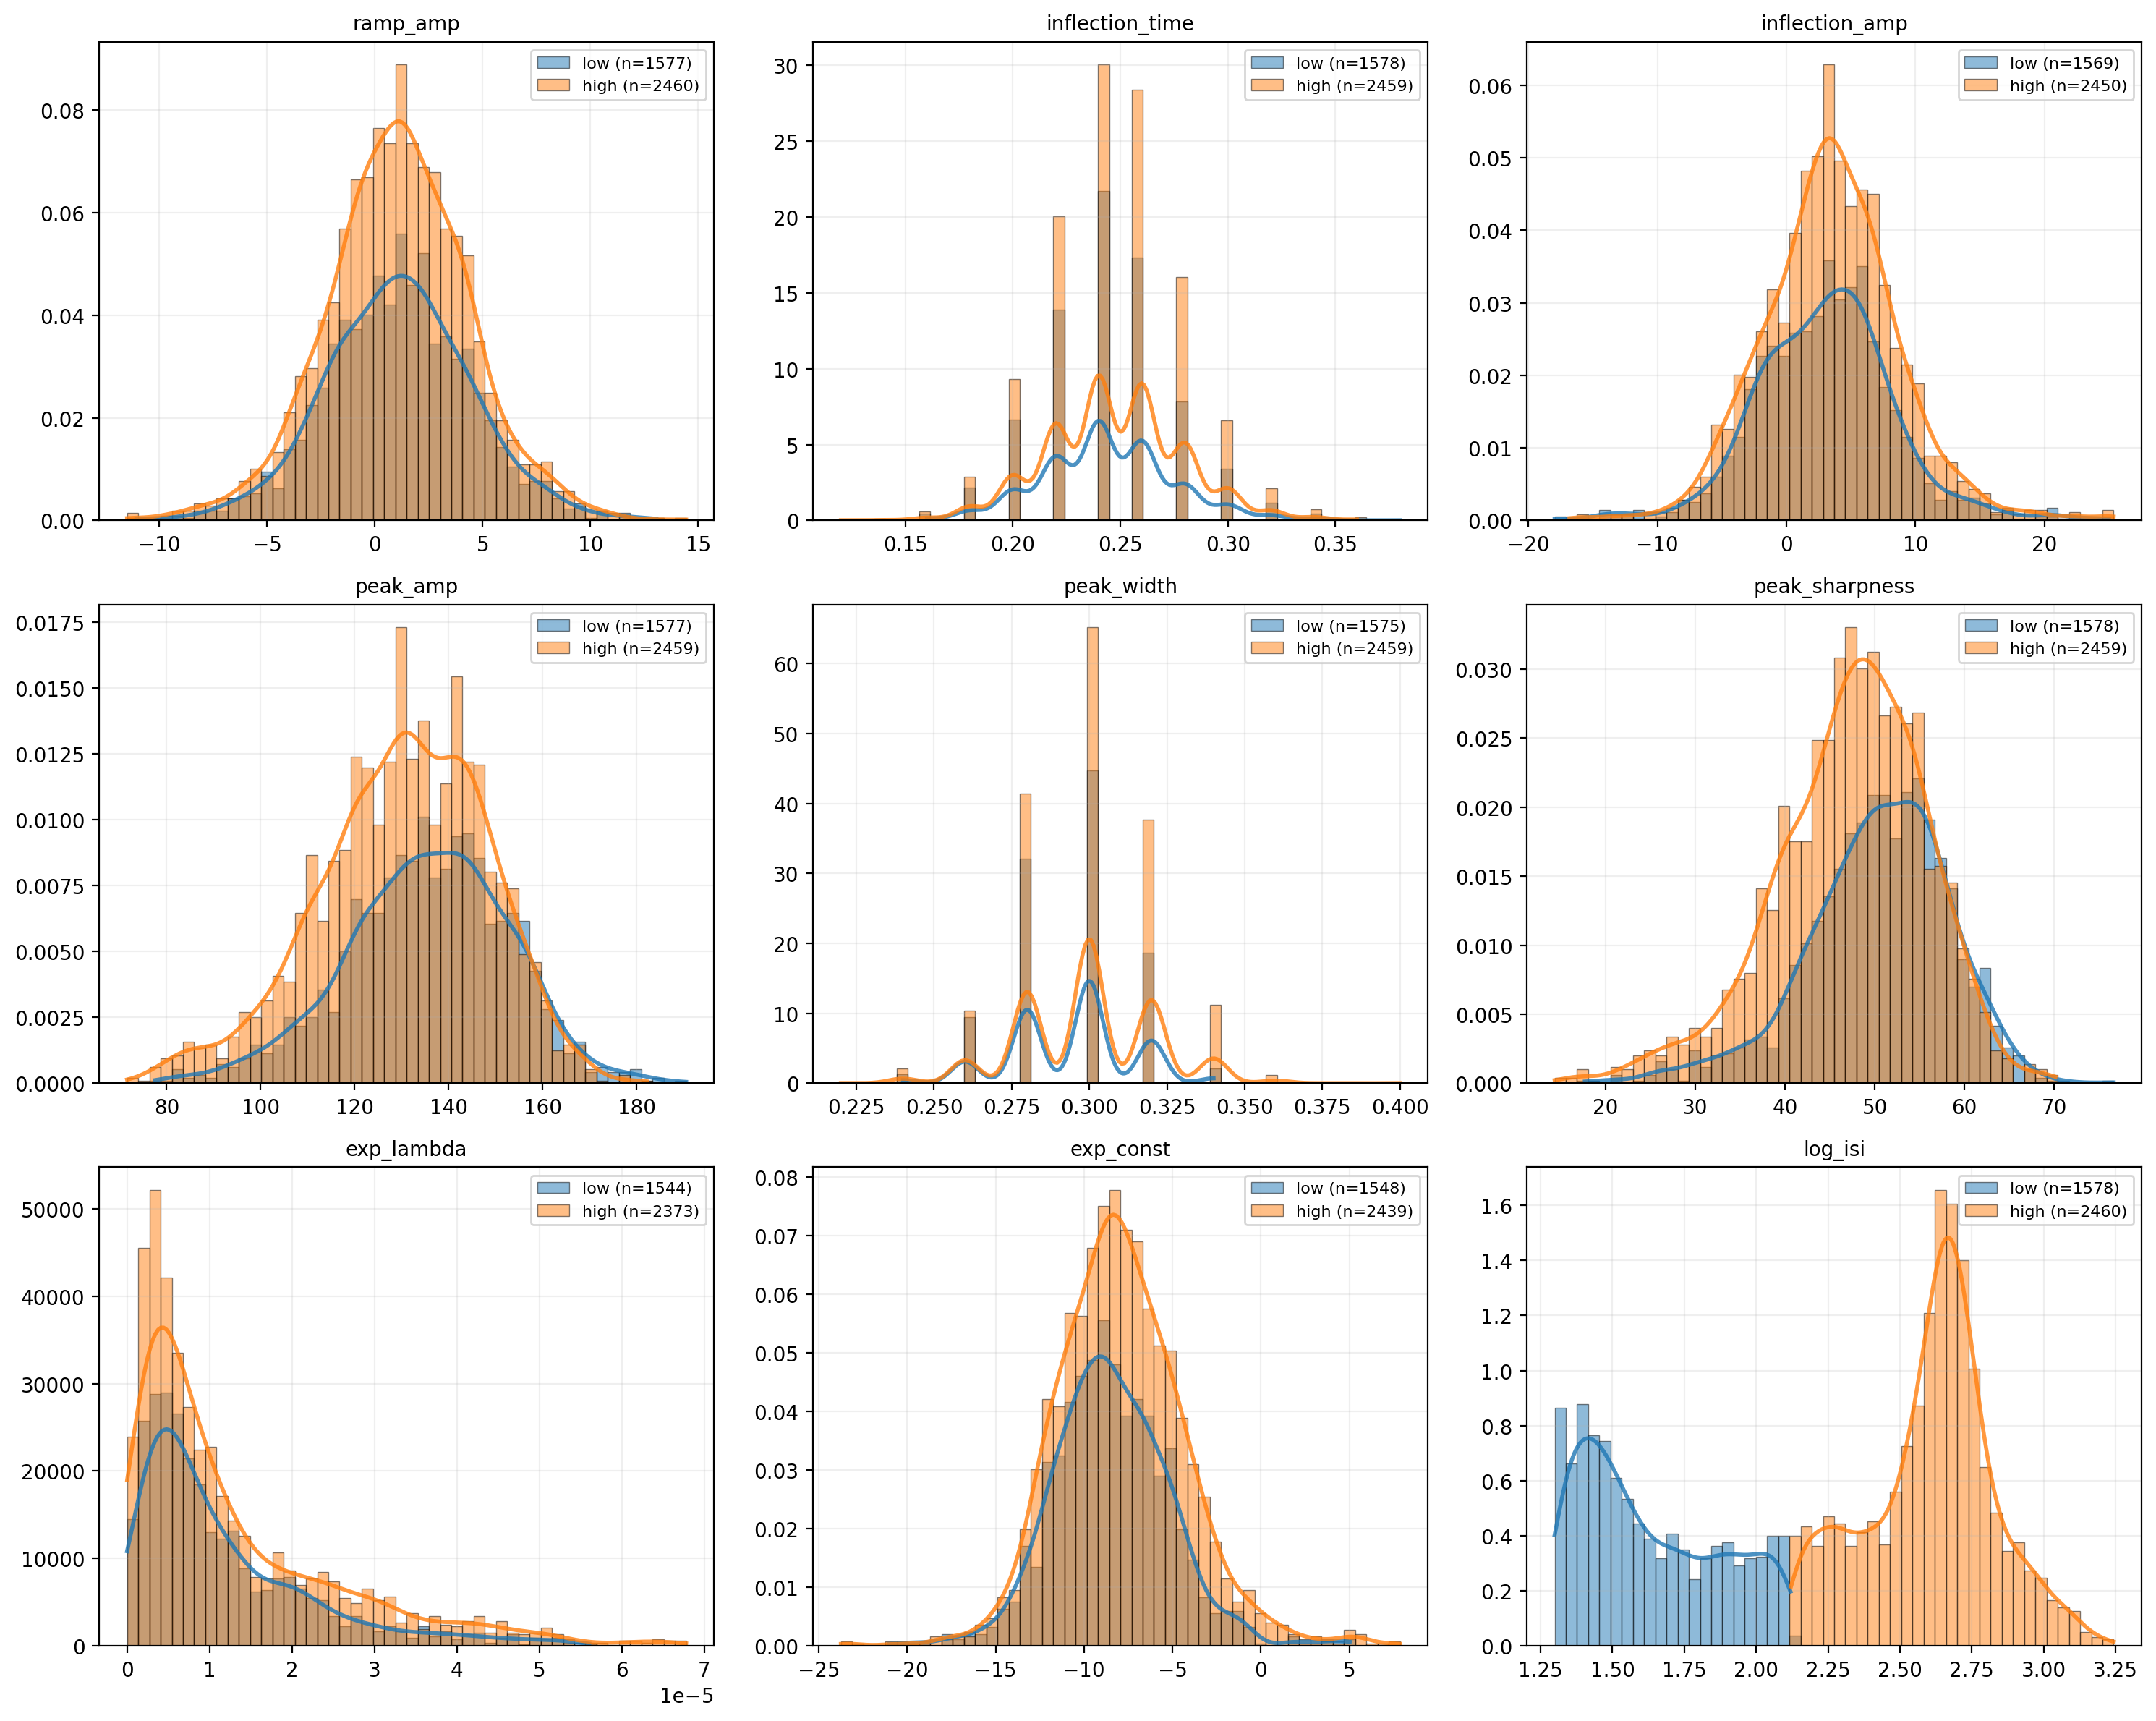


→ 5. Statistical analysis for: log_isi
----------------------------------------

Test: Mann-Whitney U (nonparametric)
Number of groups: 2
P-value: 0.000000
Significance: ***
η² effect size: 0.809
Interpretation: Very Large


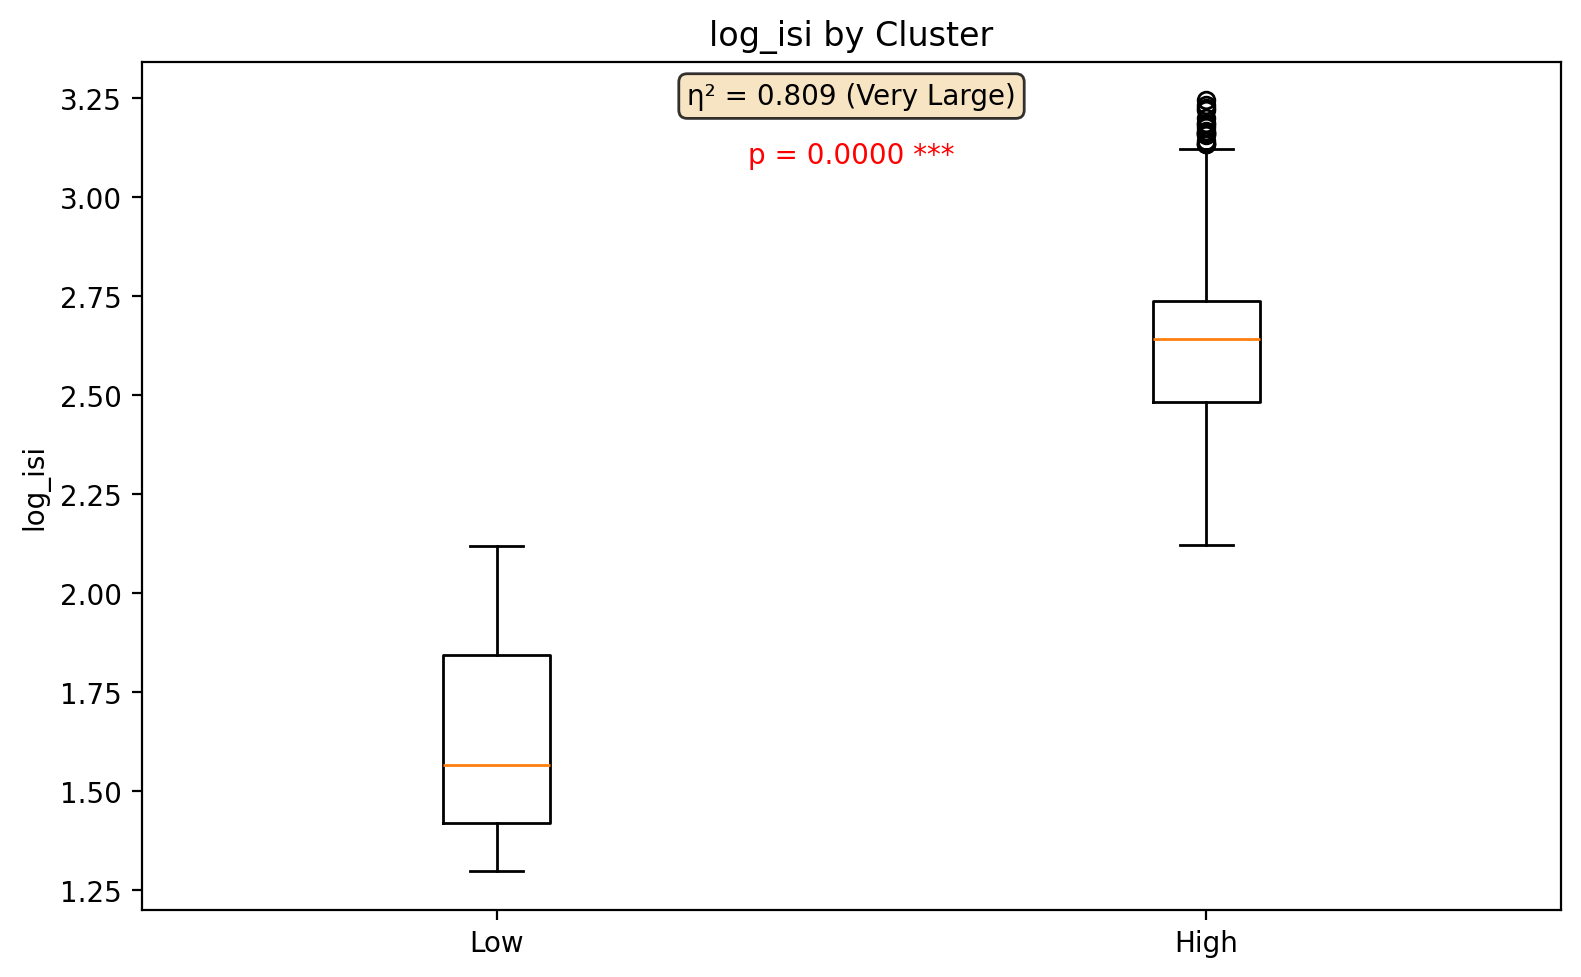


===== REPORT COMPLETE =====



In [18]:
all_reports = []

# Filter columns first to ensure the index is continuous
cluster_cols = [c for c in df_features_clust.columns if c.endswith("_cluster")]

for i, col in enumerate(cluster_cols):
    # Pass 'i' as the cluster_group_id
    row_df = plot_full_cluster_report(df_features_clust, sp, col, cluster_group_id=i)
    all_reports.append(row_df)

# Final Master DataFrame
master_report_df = pd.concat(all_reports, ignore_index=True)

In [19]:
#export cluster info df 

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/c26_df_clusters.pkl', 'wb') as file:
    pickle.dump(master_report_df, file)